# Machine learning approach 

During this notebook, we are testing different ML algorithms to tackle hypoglycemia prediction problem  

Create our own class to compare different models against several horizons and metrics

In [1]:
import os 
import pandas as pd 
import numpy as np 
from sklearn.metrics import mean_squared_error, mean_absolute_error, mean_absolute_percentage_error
from sklearn.model_selection import TimeSeriesSplit
from sklearn.base import clone
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
import sys
sys.path.append("..")
from scripts.window_regressor import Window_Regressor_Sequence_to_scalar

In [3]:
class Models_Horizon():
    def __init__(self, cut_point:int, test_size:float , window_size:int, horizon:int, folds:int, models:list, model_names:list, metrics:list):
        self.cut_point = cut_point
        self.test_size = test_size
        self.window_size = window_size
        self.horizon = horizon
        self.folds = folds
        self.models = models
        self.model_names = model_names
        self.metrics = metrics


        self.patients = self.load_patients()
        self.results = None
    
    def load_patients(self):
        data_dir = '../Data/Preprocessed'
        base_paths = os.listdir(data_dir)
        full_paths = [os.path.join(data_dir, p) for p in base_paths]
        patients = {}
        spliter = TimeSeriesSplit(n_splits=self.folds, test_size=288) ## We test using one day
        for i, fp in enumerate(full_paths):
            key = base_paths[i].split('.')[0]
            patients[key] = []
            data = pd.read_csv(fp, sep=';')[:self.cut_point]['glucose']
            for k_fold in spliter.split(data):
                k_train = data[k_fold[0]]
                k_test = data[k_fold[1]]
                proper_ml_train_k_fold = Window_Regressor_Sequence_to_scalar(time_series_data=k_train, window_size=self.window_size, horizon=self.horizon)
                proper_ml_test_k_fold = Window_Regressor_Sequence_to_scalar(time_series_data=k_test, window_size=self.window_size, horizon=self.horizon)
                patients[key].append((proper_ml_train_k_fold.generated_data_set, proper_ml_test_k_fold.generated_data_set))
        return patients
    
    def test_models(self):
        keys = list(self.patients.keys())
        results = []
        for key in keys:
            data_folds = self.patients[key] ## A list of tuples 
            columns = data_folds[0][0].columns ## Just to extract columns
            tensor_results_metrics = np.zeros(shape=(len(self.model_names), len(self.metrics), self.folds)) ## 3 cause, we're measuring MSE,MAE and MAPE

            for k, fold in enumerate(data_folds):
                train_k, test_k = fold[0], fold[1]
                X_train_k, y_train_k = train_k[columns[:-1]], train_k[columns[-1]]
                X_test_k, y_test_k = test_k[columns[:-1]], test_k[columns[-1]]
                for m, model in enumerate(self.models):
                    model = clone(model)
                    model.fit(X_train_k, y_train_k)
                    y_pred_k = model.predict(X_test_k)
                    for z, metric in enumerate(self.metrics):
                        result_metric = metric(y_true=y_test_k, y_pred=y_pred_k)
                        tensor_results_metrics[m][z][k] = result_metric
                        
            mse_all_models = tensor_results_metrics[:, 0, :]
            mae_all_models = tensor_results_metrics[:, 1, :]
            mape_all_models = tensor_results_metrics[:, 2, :]

            results.append(list(np.mean(mse_all_models, axis=1)) + list(np.mean(mae_all_models, axis=1)) + list(np.mean(mape_all_models, axis=1)))

        ### Prepare and return a df 
        metrics = ['mse', 'mae', 'mape']
        col_index = pd.MultiIndex.from_product([metrics, self.model_names], names=['metric', 'model'])
        df_final = pd.DataFrame(
            results,
            index=keys,
            columns=col_index
        )
        self.results = df_final
        return df_final

    def visualize_model_comparison(self, figsize=(15, 7)):
        if self.results is None:
            raise ValueError("No results to visualize. Run 'test_models()' first.")
    

        metrics = ['mse', 'mae', 'mape']
        model_names = self.model_names

        _, axes = plt.subplots(1, 3, figsize=figsize)
        colors = ['steelblue', 'seagreen', 'tomato']

        for ax, metric, color in zip(axes, metrics, colors):

            data_plot = self.results[metric]  

            data_long = data_plot.reset_index().melt(
                id_vars='index',
                var_name='Model',
                value_name=metric.upper()
            )
            data_long['Model'] = pd.Categorical(data_long['Model'], categories=model_names)

    
            sns.boxplot(
                data=data_long,
                x='Model',
                y=metric.upper(),
                ax=ax,
                color=color,
                width=0.6
            )

            ax.set_title(f'{metric.upper()}: Window_size:{self.window_size}, Horizon:{self.horizon}')
            ax.set_xlabel('Modelo')
            ax.set_ylabel(metric.upper())
            ax.tick_params(axis='x', rotation=45)
            ax.grid(axis='y', linestyle='--', alpha=0.7)

        plt.tight_layout()
        plt.show()
        
        ## Visualize a summary for each metric
        for m in metrics:
            print(f'{m.upper()}')
            print(self.results[m].describe())
        

## Test it using random forest regressor and gradient boost regressor 

In [4]:
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from xgboost import XGBRegressor
from catboost import CatBoostRegressor
from sklearn.linear_model import LinearRegression
from sklearn.neighbors import KNeighborsRegressor
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import MinMaxScaler


In [ ]:
cut_point = 2290
test_size = 0.2
window_size = 6
horizon = 6
folds = 5
models = [
    RandomForestRegressor(
        n_estimators=100,
        max_depth=3,          
        min_samples_split=10,
        min_samples_leaf=5,
        random_state=42
    ),
    GradientBoostingRegressor(
        n_estimators=100,
        learning_rate=0.1,
        max_depth=3,          
        min_samples_split=10,
        min_samples_leaf=5,
        subsample=0.8,
        random_state=42
    ),
    XGBRegressor(
        n_estimators=100,
        learning_rate=0.1,
        max_depth=3,          
        min_child_weight=10,  
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        objective='reg:squarederror'
    ),
    Pipeline(steps=[('scaler', MinMaxScaler(feature_range=(0,1))), ('model', LinearRegression())]),
    Pipeline(steps=[('scaler', MinMaxScaler(feature_range=(0,1))), ('model',  KNeighborsRegressor(
    n_neighbors=5,
    weights='distance'  
    ))]),
    CatBoostRegressor(
    iterations=100,
    learning_rate=0.1,
    depth=3,
    random_seed=42,
    verbose=False
)

]
model_names = ['random_forest', 'gradient_boost', 'xgboost', 'linear_regression', 'KNN_regressor', 'CatBoost']
metrics = [mean_squared_error, mean_absolute_error, mean_absolute_percentage_error]

In [6]:
horizon_3 = Models_Horizon(
    cut_point=cut_point, 
    test_size=test_size, 
    window_size=window_size, 
    horizon=horizon, 
    folds=folds,
    models=models, 
    model_names=model_names, 
    metrics=metrics
)

In [7]:
results = horizon_3.test_models()

In [8]:
results.shape

(25, 18)

In [9]:
results

metric              mse                                                \
model     random_forest gradient_boost      xgboost linear_regression   
HUPA0004P    854.190016     497.505012   590.377730        351.756402   
HUPA0006P    820.230737     642.099247   704.679019        289.331297   
HUPA0007P   1295.452377    1060.447275  1114.486599       1027.038549   
HUPA0009P    210.556321     220.828381   185.746547         63.172596   
HUPA0005P    383.253171     358.160958   377.467062        304.676175   
HUPA0011P   1008.687368     871.109361   935.976951        572.037478   
HUPA0003P    564.611648     507.419767   514.259678        418.191906   
HUPA0001P   1256.354694    1093.971139  1106.549553        889.503029   
HUPA0010P    714.692895     483.436316   528.118706        341.129306   
HUPA0002P    372.473976     313.528771   339.301027        186.140274   
HUPA0014P   1075.266157     945.553426   967.346287        273.544229   
HUPA0015P    679.550085     516.527394   570.442006        323.543846   
HUPA0016P    599.597948     439.887824   467.770421        310.274479   
HUPA0017P    474.469511     379.089502   396.670778        285.081144   
HUPA0018P    683.161673     473.107637   498.867867        301.788630   
HUPA0021P    691.885507     565.616184   604.110649        374.599081   
HUPA0020P    605.991973     430.646840   464.486749        280.771966   
HUPA0024P    557.600609     333.716352   354.176817        222.680961   
HUPA0019P   1040.831182     713.596956   757.813513        504.183585   
HUPA0023P    497.454089     416.849745   434.400387        254.554131   
HUPA0022P    291.147622     286.472501   287.101431        253.849783   
HUPA0025P    289.089956     252.587499   269.050105        160.613416   
HUPA0028P    528.520752     432.249373   457.124223        308.541558   
HUPA0026P    585.406845     420.288815   461.822280        300.816710   
HUPA0027P    293.331342     252.223613   268.255631        197.450302   

metric                                         mae                            \
model     KNN_regressor     CatBoost random_forest gradient_boost    xgboost   
HUPA0004P    672.415657   640.774462     22.412611      16.709834  18.269255   
HUPA0006P    764.492896   719.719991     21.804170      18.668756  19.878409   
HUPA0007P   1238.696220  1110.281799     27.774071      24.189808  25.009401   
HUPA0009P    203.855819   237.716863     10.133731       7.924119   7.757204   
HUPA0005P    483.691906   368.454661     14.619488      14.263799  14.785041   
HUPA0011P   1039.039505   906.187692     22.793246      21.430463  22.155317   
HUPA0003P    555.277875   505.455219     18.422364      16.662125  16.915571   
HUPA0001P   1464.085922  1140.418011     25.785272      23.511822  24.106664   
HUPA0010P    576.979169   557.137958     17.216116      12.770625  13.612779   
HUPA0002P    412.732322   331.984806     14.484701      13.639687  14.175527   
HUPA0014P   1107.711126   952.372922     19.431003      16.799399  17.290236   
HUPA0015P    613.154011   555.413986     18.765392      16.558180  17.456621   
HUPA0016P    567.687272   504.738324     17.851849      15.563949  16.150454   
HUPA0017P    471.699997   416.789557     16.608789      14.639849  15.048823   
HUPA0018P    596.051128   536.664895     20.174134      15.937330  16.424373   
HUPA0021P    659.796455   577.230431     19.750556      17.305327  18.064198   
HUPA0020P    521.204635   511.481281     19.411022      15.992778  16.739770   
HUPA0024P    429.964175   402.349618     17.700758      14.079312  14.459539   
HUPA0019P    974.710379   799.068969     23.172738      19.189048  19.935539   
HUPA0023P    480.731211   421.350544     16.188778      14.440832  14.912332   
HUPA0022P    320.860928   286.504412     13.058625      12.913683  12.916902   
HUPA0025P    284.479437   266.505012     13.065006      11.743148  12.272012   
HUPA0028P    478.961453   448.439269     16.791133      14.639104  15.141432   
HUPA0026P    594.012561   48

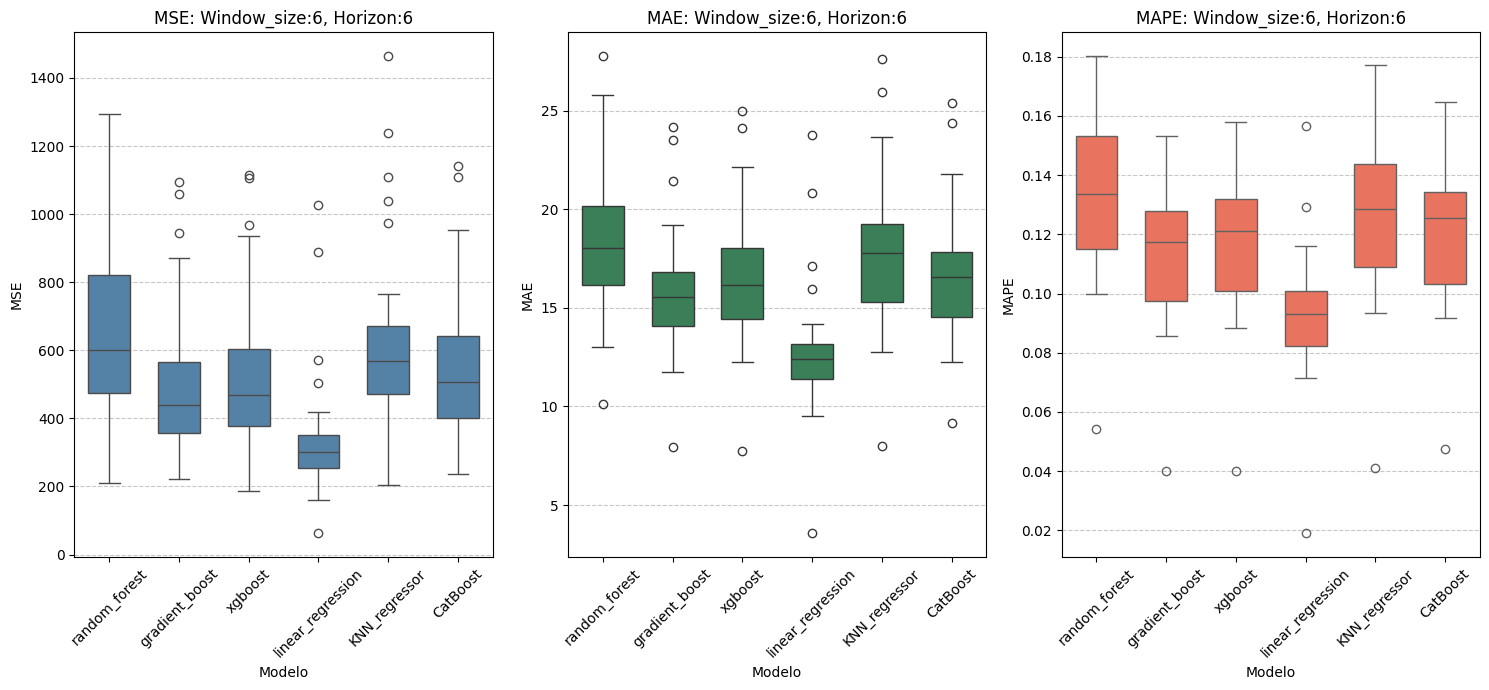

MSE
model  random_forest  gradient_boost      xgboost  linear_regression  \
count      25.000000       25.000000    25.000000          25.000000   
mean      654.952338      516.276795   546.256081         351.810833   
std       298.980813      244.740549   255.573136         210.151150   
min       210.556321      220.828381   185.746547          63.172596   
25%       474.469511      358.160958   377.467062         254.554131   
50%       599.597948      439.887824   467.770421         301.788630   
75%       820.230737      565.616184   604.110649         351.756402   
max      1295.452377     1093.971139  1114.486599        1027.038549   

model  KNN_regressor     CatBoost  
count      25.000000    25.000000  
mean      634.042272   558.423167  
std       308.755268   252.194830  
min       203.855819   237.716863  
25%       471.699997   402.349618  
50%       567.687272   505.455219  
75%       672.415657   640.774462  
max      1464.085922  1140.418011  
MAE
model  random_fores

In [10]:
horizon_3.visualize_model_comparison()